### Objective and setup

##### From "what's in the data?" to "what actually drives churn?" - which customer segments are at highest churn risk, and what patterns matter for the business?

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.style.use("seaborn-v0_8") 
sns.set(font_scale=1.1) 

df = pd.read_csv("C:/Users/tchat/OneDrive/Documents/Passion Projects/Telco Churn Project/Data/telco_churn_cleaned.csv") 
df.head() 
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

### Univariate analysis (distributions)

##### Goal: understand each feature on its own and flag any remainning issues

C:\Users\tchat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\tchat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\tchat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


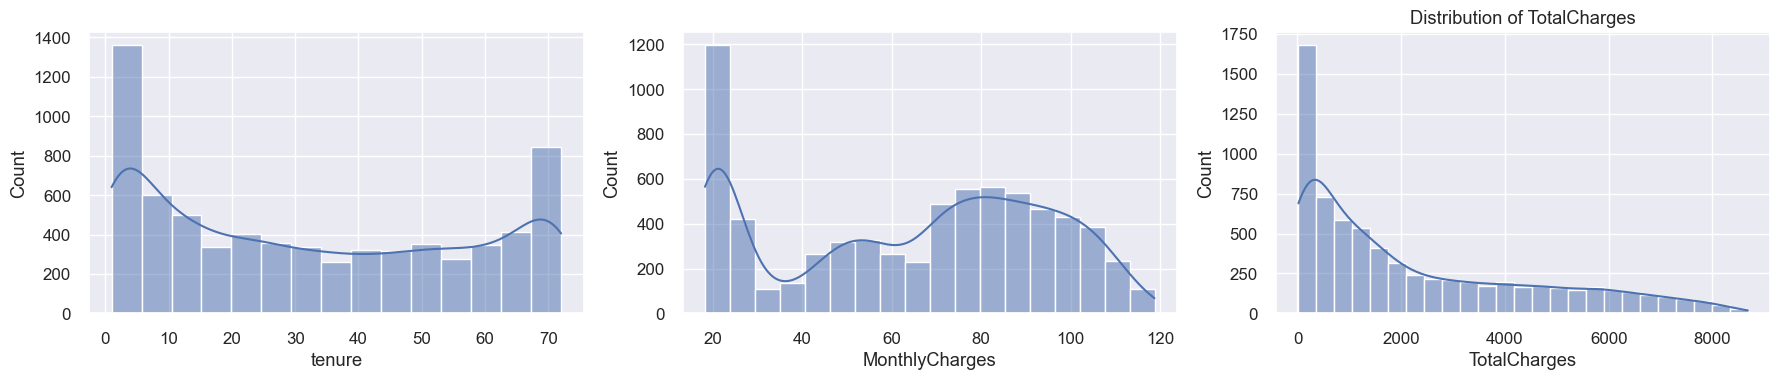

In [5]:
# Numeric features: 

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"] 

df[num_cols].describe() 

fig, axes = plt.subplots(1, 3, figsize=(18, 4)) 
for ax, col in zip(axes, num_cols): 
    sns.histplot(data=df, x=col, kde=True, ax=ax) 
ax.set_title(f"Distribution of {col}") 
plt.tight_layout()

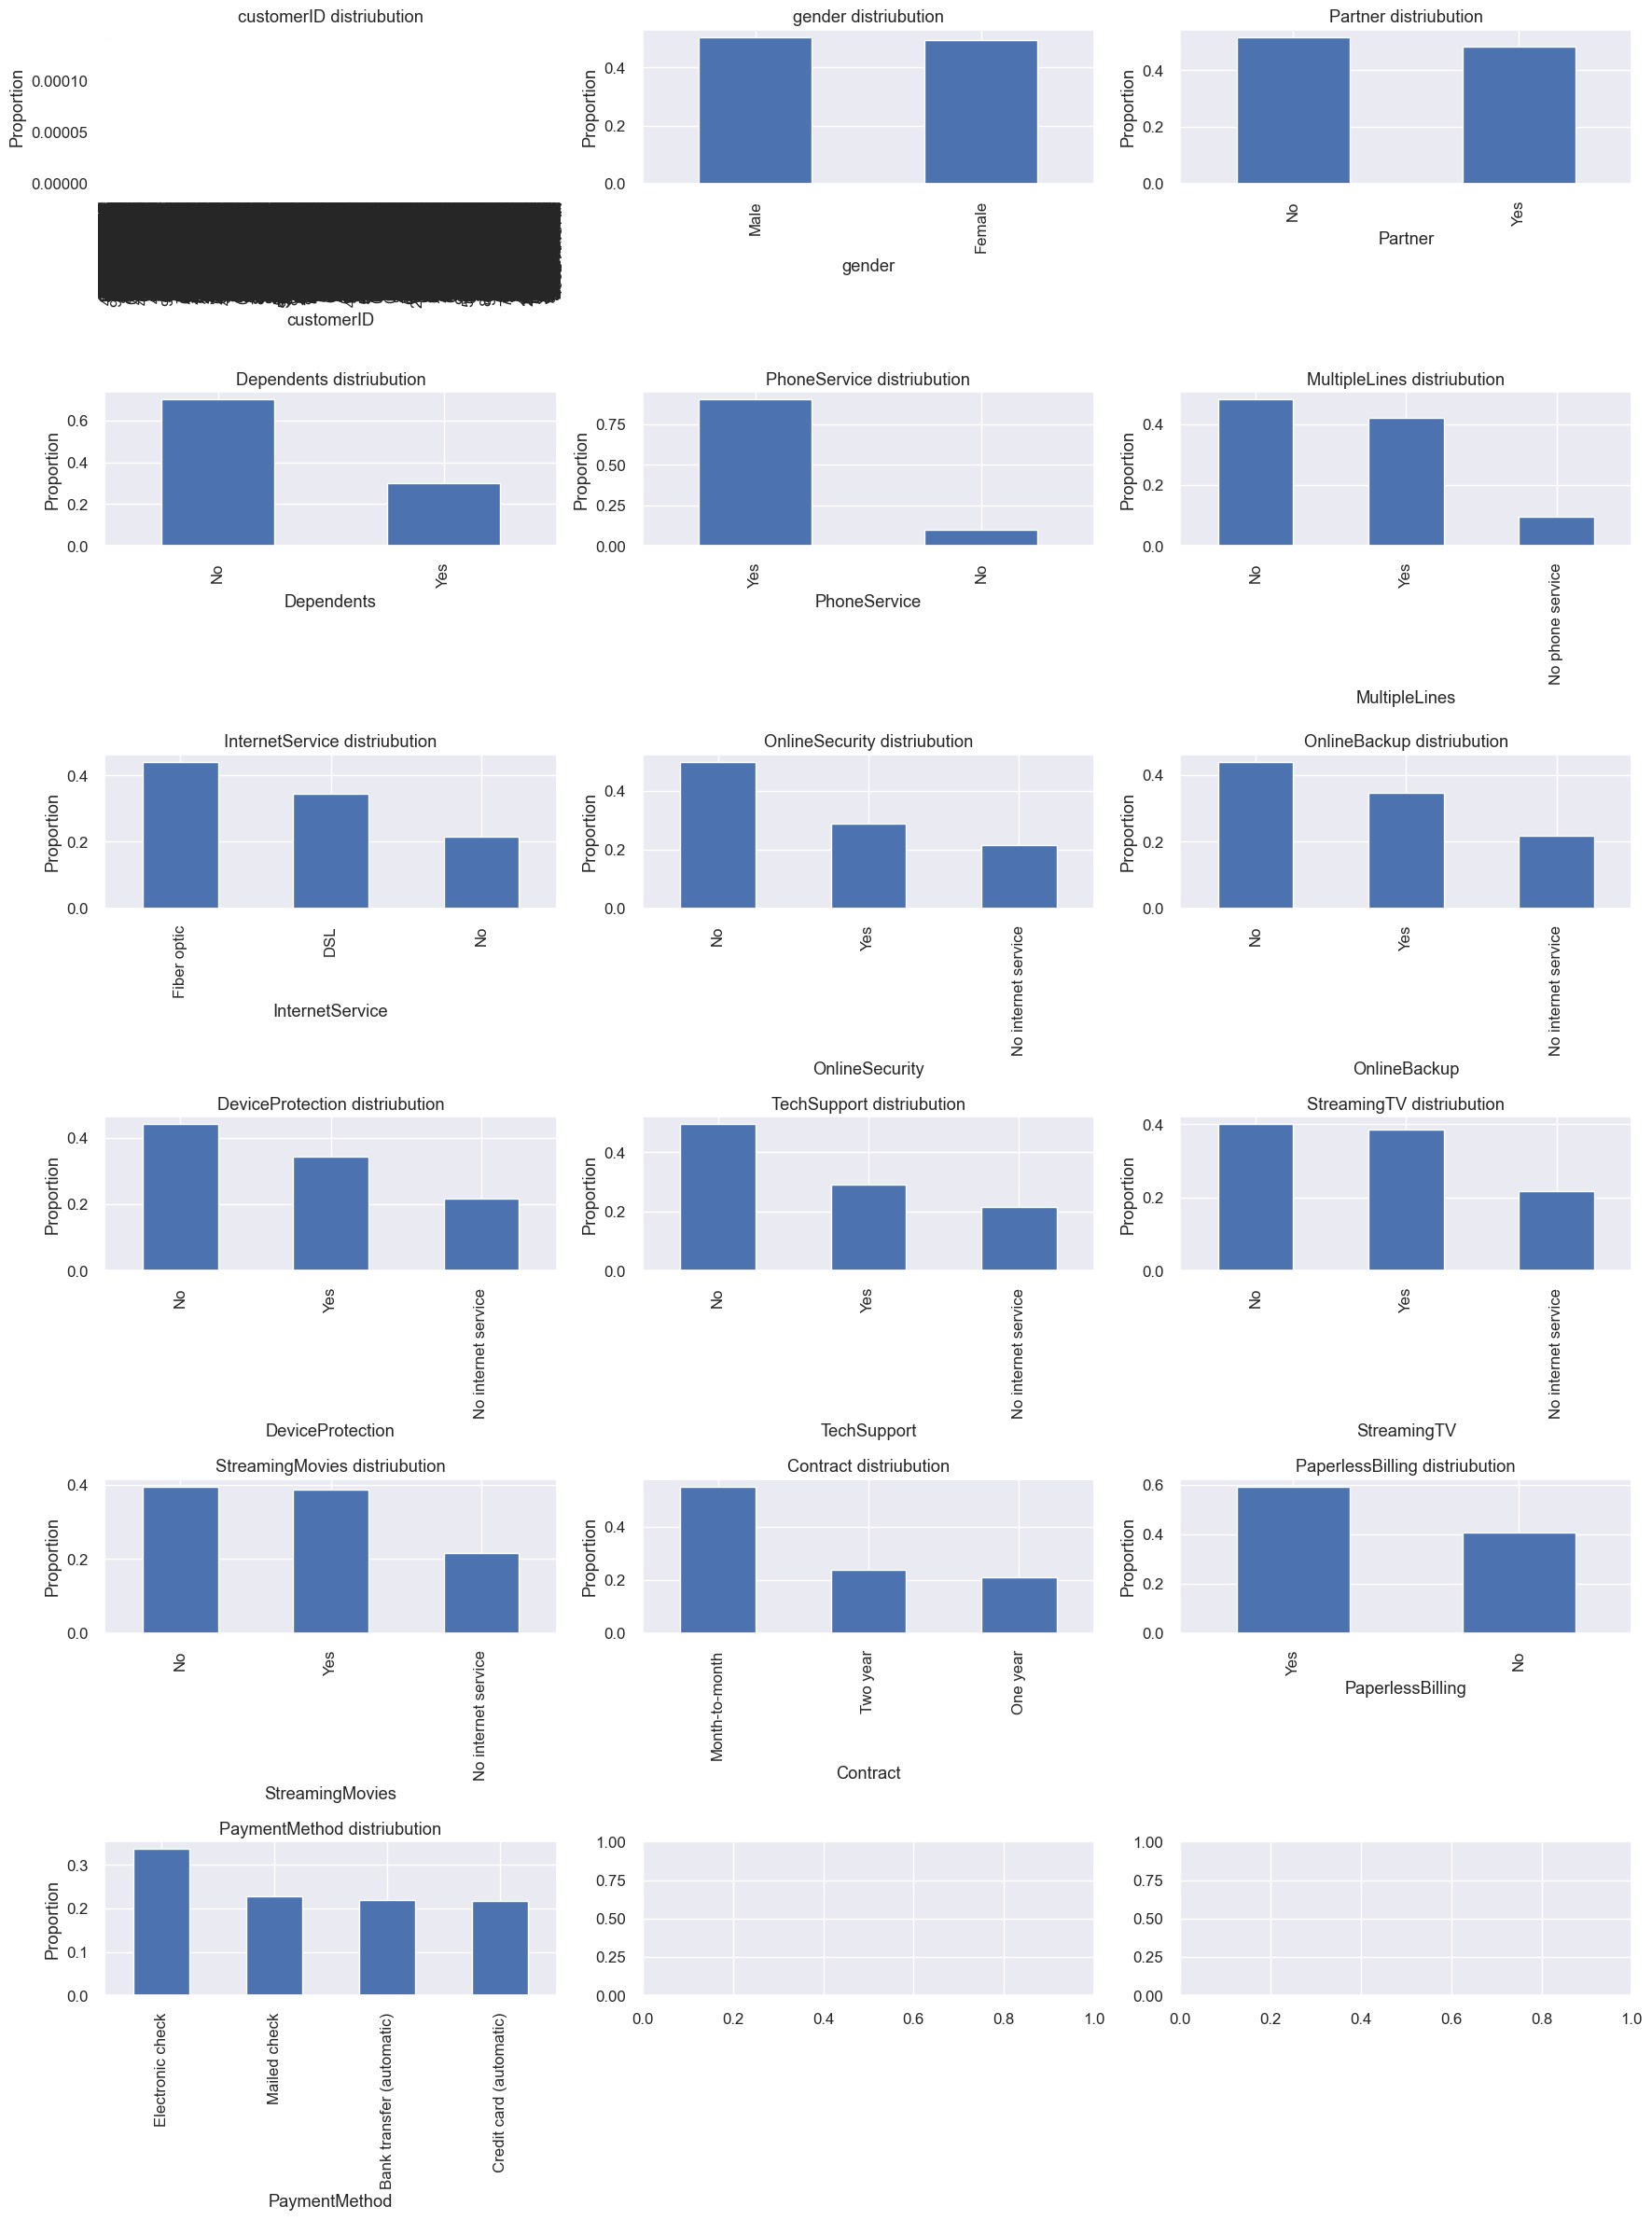

In [6]:
# Categorical features:

cat_cols = df.select_dtypes(include="object").columns.tolist() 

fig, axes = plt.subplots(len(cat_cols)//3 + 1, 3, figsize=(18, 4 * (len(cat_cols)//3 + 1)))
axes = axes.flatten() 

for ax, col in zip(axes, cat_cols): 
    (df[col] 
     .value_counts(normalize=True) 
     .plot(kind="bar", ax=ax)) 
    ax.set_title(f"{col} distriubution") 
    ax.set_ylabel("Proportion")
plt.tight_layout()

### Bivariate analysis vs churn (core of the notebook)

##### Heart of the EDA - focus on the business-relevant relationships: 
Churn vs contract type

Churn vs tenure (and tenure groups)

Churn vs payment method

Churn vs internet service and add‑ons (OnlineSecurity, TechSupport, etc.)

Churn vs monthly charges / total charges

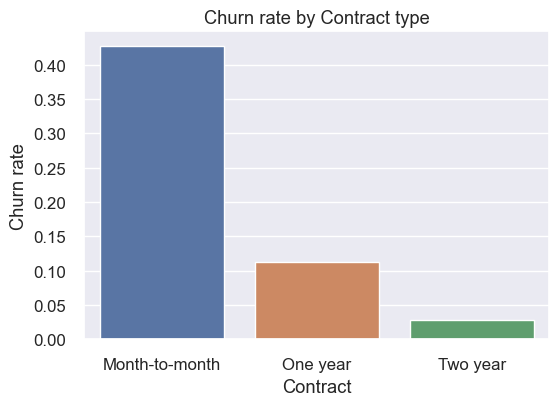

In [7]:
contract_churn = (
    df.groupby("Contract")["Churn"] 
    .mean() 
    .sort_values(ascending=False) 
) 

plt.figure(figsize=(6,4)) 
sns.barplot(x=contract_churn.index, y=contract_churn.values) 
plt.ylabel("Churn rate") 
plt.title("Churn rate by Contract type") 
plt.show()

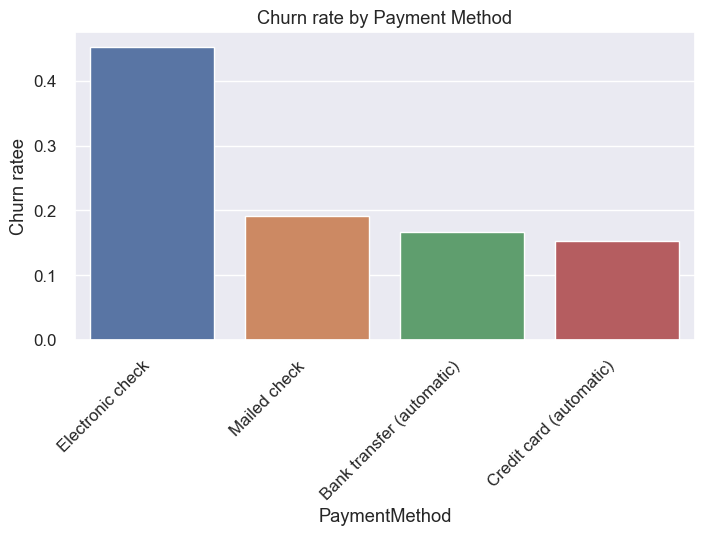

In [9]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"] 
        .mean() 
        .sort_values(ascending=False) 
) 
plt.figure(figsize=(8,4)) 
sns.barplot(x=payment_churn.index, y=payment_churn.values) 
plt.xticks(rotation=45, ha="right") 
plt.ylabel("Churn ratee") 
plt.title("Churn rate by Payment Method") 
plt.show()

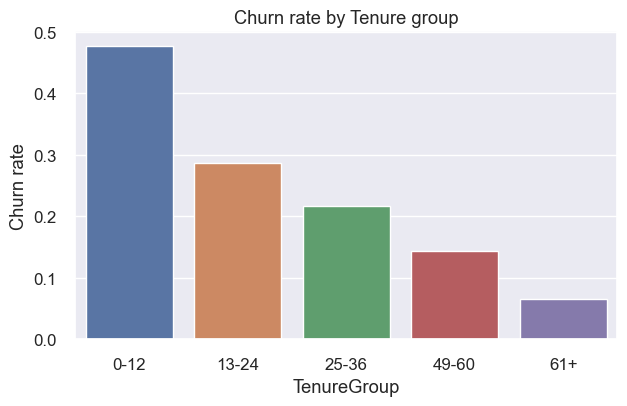

In [11]:
def tenure_group(t):
    if t <= 12:
        return "0-12" 
    elif t <= 24: 
        return "13-24" 
    elif t <= 36: 
        return "25-36" 
    elif t <= 48: 
        return "37-48"
    elif t <= 60: 
        return "49-60" 
    else:
        return "61+"

df["TenureGroup"] = df["tenure"].apply(tenure_group) 

tg_churn = (
    df.groupby("TenureGroup")["Churn"] 
    .mean()
    .reindex(["0-12", "13-24", "25-36", "49-60", "61+"]) 
)

plt.figure(figsize=(7,4))
sns.barplot(x=tg_churn.index, y=tg_churn.values) 
plt.ylabel("Churn rate") 
plt.title("Churn rate by Tenure group") 
plt.show()

### Correlation and numeric relationships

##### Correlation matrix for numeric variables to see which ones correlate most with churn, as well as each other

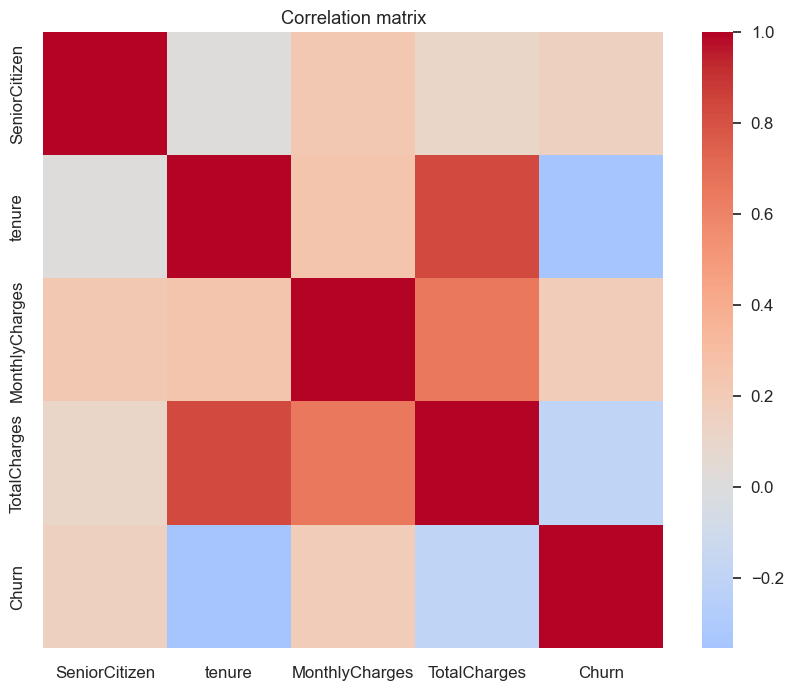

Churn             1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64

In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist() 

corr = df[num_cols].corr()

plt.figure(figsize=(10,8)) 
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0) 
plt.title("Correlation matrix") 
plt.show() 

corr["Churn"].sort_values(ascending=False)